# Multi parameter perturbation

Doing the code for multiple parameter to study how sensitive a neuron’s spiking behavior is to changes in its biophysical ion-channel parameters.

three biophysical parameters:
Sodium conductance → gnabar_hh,
Potassium conductance → gkbar_hh,
Leak conductance → gl_hh

In [118]:
from neuron import h,gui
import numpy as np
import matplotlib.pyplot as plt

In [119]:
soma=h.Section(name="soma")
soma.L=20
soma.cm=1
soma.insert("hh")

soma

In [120]:
stim=h.IClamp(soma(0.5))
stim.delay=100
stim.dur=100
stim.amp=0.7  #nA

In [121]:
v_vec=h.Vector().record(soma(0.5)._ref_v)
t_vec=h.Vector().record(h._ref_t)

In [122]:
def detect_spikes(voltage, time, threshold=0):
    spikes = []
    for i in range (1, len(voltage)):
        if voltage[i-1] < threshold and voltage[i] >= threshold:
            spikes.append(time[i])
    return np.array(spikes)

In [123]:
def run_simulation():
    h.tstop = 700
    h.v_init = -65
    h.run()

    voltage = np.array(v_vec)
    time = np.array(t_vec)

    spikes = detect_spikes(voltage, time)
    firing_rate = len(spikes) / (stim.dur / 1000)  #Hz

    return firing_rate

In [124]:
parameters ={
    "gNa": ("gnabar_hh",soma.gnabar_hh),
    "gK" : ("gkbar_hh", soma.gkbar_hh),
    "gL" : ("gl_hh", soma.gl_hh)
}

scales = np.linspace(0.7, 1.3, 7)

## Multi-parameter perturbation loop

In [125]:
result = {}

baseline_rate = run_simulation()

for param_name, (attr,base_value) in parameters.items():
    rates = []

    for scale in scales:
        setattr(soma, attr, base_value*scale)
        rate = run_simulation()
        rates.append(rate)


    setattr(soma, attr, base_value)


    result[param_name] = np.array(rates)

### Sensitivity calculation

In [126]:
sensitivities = {}

for param in result:
    delta_rate = result[param] - baseline_rate
    delta_param = scales - 1.0
    sensitivity = np.mean(delta_rate / delta_param)
    sensitivities[param] = sensitivity

C:\Users\abhia\AppData\Local\Temp\ipykernel_10228\2806776144.py:6: RuntimeWarning: invalid value encountered in divide
  sensitivity = np.mean(delta_rate / delta_param)


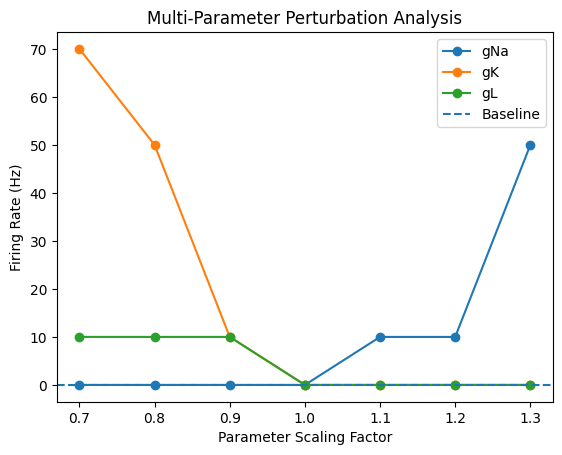

In [127]:
plt.figure()

for param in result:
    plt.plot(scales, result[param], marker='o', label=param)

plt.axhline(baseline_rate, linestyle= '--', label="Baseline")
plt.xlabel("Parameter Scaling Factor")
plt.ylabel("Firing Rate (Hz)")
plt.title("Multi-Parameter Perturbation Analysis")
plt.legend()
plt.show()

In [128]:
print("Sensitivity Analysis (ΔFiring Rate / ΔParameter):\n")
for param, sens in sensitivities.items():
    print(f"{param}: {sens:.2f}")


Sensitivity Analysis (ΔFiring Rate / ΔParameter):

gNa: nan
gK: nan
gL: nan


## Interpretation of Multi-Parameter Perturbation Results (0.7 nA)

- At **0.7 nA injected current**, the neuron operates in a **strongly suprathreshold regime**, exhibiting high baseline excitability.

- Overall firing rates increase compared to **0.5 nA**, indicating that the neuron is now **well above firing threshold** and less limited by spike initiation constraints.

- **Potassium conductance (gK) remains the dominant regulator of firing rate**:
  - Reducing gK leads to **very high firing rates**, reflecting weakened repolarization and shortened refractory periods.
  - Increasing gK strongly suppresses firing, even under high current injection.
  - This confirms potassium channels as the **primary stabilizing mechanism** against excessive excitation.

- **Sodium conductance (gNa) shows a reduced but still noticeable influence**:
  - Since the neuron is already far above threshold, increasing gNa produces only **modest changes in firing rate**.
  - This indicates that sodium channels are **less rate-limiting** once repetitive spiking is established.

- **Leak conductance (gL) has minimal effect** on firing rate at this current level:
  - Variations in gL do not significantly alter spike output.
  - Leak channels mainly influence **subthreshold membrane dynamics**, which are largely overridden in this regime.

- The firing-rate response exhibits **nonlinear saturation**, where further increases in excitatory parameters yield diminishing effects.
